Data analysis on diabetes-related medical information

### Important: this is a synthetic dataset. It is intended to mimick patterns found in a real dataset, but the datapoints do not represent real patients

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

pd.set_option('display.max_columns', 504) 
pd.set_option('display.max_rows', None)


In [121]:
path = kagglehub.dataset_download(
    "mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients"
)

print("Dataset downloaded to:", path)
print("Files:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))


Dataset downloaded to: C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1
Files:
C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv


Gathering data profile 

In [122]:
diabetes_data = pd.read_csv(r"C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv")
diabetes_df = pd.DataFrame(diabetes_data)
ini_N_rows = diabetes_df.shape[0]
#print(diabetes_df.head())
print("---------")
print(diabetes_df.info())
print("---------")
print(diabetes_df.shape)

---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diasto

In [123]:
display(diabetes_df.head())

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Physical_Activity_Level,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Diet_Quality,Sugar_Intake_Level,Sleep_Hours,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,27.4,94,61,138.7,40.1,152.3,250.8,119,Moderate,2.2,106.1,Healthy,Low,7.9,Moderate,Former,Never,Yes,No,Yes,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,18.3,148,100,286.8,35.6,110.4,287.9,59,High,6.3,96.1,Healthy,Low,6.2,Moderate,Current,Frequently,Yes,No,Yes,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,23.9,101,108,129.4,32.1,156.7,329.3,104,High,0.6,68.7,Average,High,4.8,High,Never,Frequently,Yes,No,No,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,217.7,36.7,120,63,168.2,61.9,63.4,308.8,58,High,7.7,23.1,Average,High,4.2,High,Current,Occasionally,Yes,Yes,No,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,153.5,22.3,190,90,281.5,37.4,66.5,206.6,104,Moderate,4.7,131.2,Poor,High,9.9,Low,Never,Occasionally,No,Yes,Yes,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


In [124]:
diabetes_df.describe().round()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.0,49503.0,47055.0,47038.0,50000.0,50000.0,49041.0,48026.0,50000.0,50000.0,50000.0,50000.0,49000.0,49000.0,49000.0,49000.0,50000.0,48008.0,48036.0,47983.0,50000.0,50000.0
mean,25000.0,54.0,170.0,87.0,31.0,100.0,160.0,8.0,143.0,23.0,140.0,90.0,220.0,57.0,135.0,230.0,85.0,5.0,90.0,7.0,3.0,74.0
std,14434.0,21.0,14.0,25.0,10.0,23.0,52.0,2.0,45.0,12.0,29.0,18.0,58.0,19.0,49.0,98.0,20.0,3.0,52.0,2.0,1.0,16.0
min,1.0,18.0,145.0,45.0,12.0,60.0,70.0,4.0,65.0,2.0,90.0,60.0,120.0,25.0,50.0,60.0,50.0,0.0,0.0,3.0,1.0,13.0
25%,12501.0,35.0,158.0,66.0,23.0,80.0,115.0,6.0,104.0,13.0,115.0,75.0,170.0,41.0,92.0,145.0,68.0,2.0,45.0,5.0,2.0,64.0
50%,25000.0,54.0,170.0,87.0,30.0,100.0,160.0,8.0,143.0,23.0,140.0,90.0,220.0,57.0,135.0,230.0,85.0,5.0,90.0,6.0,3.0,75.0
75%,37500.0,72.0,183.0,109.0,38.0,120.0,205.0,10.0,182.0,34.0,165.0,105.0,270.0,74.0,178.0,315.0,103.0,8.0,135.0,8.0,4.0,86.0
max,50000.0,90.0,195.0,130.0,62.0,140.0,250.0,12.0,220.0,45.0,190.0,120.0,320.0,90.0,220.0,400.0,120.0,10.0,180.0,10.0,5.0,100.0


In [125]:
#Find out on which score cut-offs, the diabetes risk category is determined
cut_off_diabetes_scores = diabetes_df.groupby("Diabetes_Risk")["Diabetes_Risk_Score"].agg(
    min_value="min",
    max_value="max"
).reset_index()

print(cut_off_diabetes_scores)

  Diabetes_Risk  min_value  max_value
0          High         65        100
1           Low         13         34
2      Moderate         35         64


Data cleaning

In [126]:
print(f"Missing values: {diabetes_df.isnull().sum()}")

Missing values: Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Fami

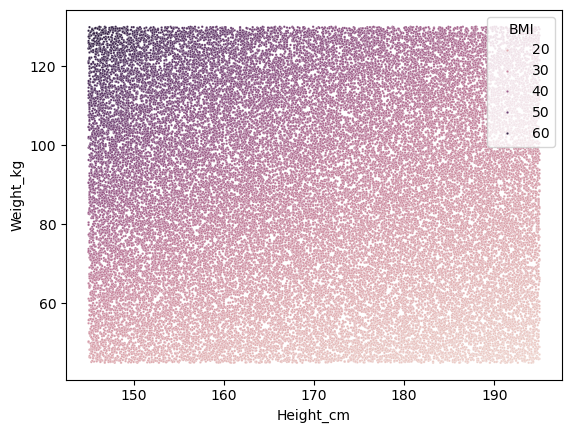

In [127]:

#plot correlation height,weight, bmi
sns.scatterplot(diabetes_df, x = 'Height_cm', y= 'Weight_kg', hue='BMI', s=3)
plt.show()
#Data integrity; Calcuation of BMI validated
#No apparent clusters of height/weight combinations in overall data
#height and weight columns will be dropped
if "Weight_kg" in diabetes_df.columns:
    diabetes_df = diabetes_df.drop(columns="Weight_kg")
if "Height_cm" in diabetes_df.columns:
    diabetes_df = diabetes_df.drop(columns="Height_cm")


#Future ossibility to explore, using bmi as stand-in for weight and height. 
#Investigate if height has no inherent influence on diabetes risk
#Or if absolute weight has more impact than BMI

In [128]:
#exclude columsn where more than 1/10th of all rows are empty, 
#for possible future changes in the data
column_cutoff = diabetes_df.shape[0]/10
print(column_cutoff)
diabetes_df = diabetes_df.dropna(axis = 1, thresh=column_cutoff)
print(diabetes_df.shape)

5000.0
(50000, 39)


In [129]:

#Drop rows with age missing. Too basic of an indicator to miss and makes up only a small % of datapoints. 
#Missing age can be nothing else than data integrity issues
#No significant bias expected in why some datapoints have no registered age.
diabetes_df= diabetes_df. dropna(axis=0, subset=['Age'])
print(diabetes_df.shape)
#Same reasoning for glucose level, with the comment that absence of this information
#might be an indicator for subpar healthcare or on the other hand, no noticable health issues to warrant 
#medical research. Significant bias not probable, but possible
#the presence of the insulin levels and fasting blood sugar will lessen any such impact
diabetes_df= diabetes_df. dropna(axis=0, subset=['Blood_Glucose'])
print(diabetes_df.shape)

current_nrows = diabetes_df.shape[0]
filteredrows = round(current_nrows/ini_N_rows *100)
print(f"Datapoints left: {filteredrows}%")

(49503, 39)
(48557, 39)
Datapoints left: 97%


In [130]:
#dealing with remaining empty values
numeric_columns = diabetes_df.select_dtypes(include="number").columns

diabetes_df[numeric_columns] = diabetes_df[numeric_columns].fillna(
    diabetes_df[numeric_columns].mean()
)


In [131]:
print(f"Missing values: {diabetes_df.isnull().sum()}")

Missing values: Patient_ID                      0
Age                             0
Gender                          0
Country                         0
BMI                             0
Waist_Circumference_cm          0
Blood_Glucose                   0
HbA1c                           0
Fasting_Blood_Sugar             0
Insulin_Level                   0
Blood_Pressure_Systolic         0
Blood_Pressure_Diastolic        0
Total_Cholesterol               0
HDL                             0
LDL                             0
Triglycerides                   0
Heart_Rate                      0
Physical_Activity_Level       491
Exercise_Hours_Per_Week         0
Daily_Walking_Minutes           0
Diet_Quality                    0
Sugar_Intake_Level              0
Sleep_Hours                     0
Stress_Level                    0
Smoking_Status                  0
Alcohol_Consumption             0
Family_History_Diabetes         0
Hypertension                    0
Heart_Disease                   

In [132]:
print(diabetes_df.value_counts(['Physical_Activity_Level']))
print(diabetes_df['Physical_Activity_Level'].isnull().sum())
diabetes_df['Physical_Activity_Level'].fillna('Unknown', inplace= True)
print(diabetes_df['Physical_Activity_Level'].isnull().sum())


Physical_Activity_Level
Low                        16200
High                       16016
Moderate                   15850
Name: count, dtype: int64
491
0


C:\Users\nicol\AppData\Local\Temp\ipykernel_20692\2026956305.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_df['Physical_Activity_Level'].fillna('Unknown', inplace= True)


In [133]:
print(diabetes_df.value_counts(['Medication_Adherence']))
print(diabetes_df['Medication_Adherence'].isnull().sum())
diabetes_df['Medication_Adherence'].fillna('Unknown', inplace= True)
print(diabetes_df['Medication_Adherence'].isnull().sum())


Medication_Adherence
Good                    15894
Average                 15875
Poor                    15823
Name: count, dtype: int64
965
0


C:\Users\nicol\AppData\Local\Temp\ipykernel_20692\726678218.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_df['Medication_Adherence'].fillna('Unknown', inplace= True)


Data exploration

In [134]:
diabetes_df.describe().round()

,Patient_ID,Age,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0,48557.0
mean,24988.0,54.0,31.0,100.0,160.0,8.0,143.0,23.0,140.0,90.0,220.0,57.0,135.0,229.0,85.0,5.0,90.0,7.0,3.0,74.0
std,14437.0,21.0,10.0,23.0,52.0,2.0,45.0,12.0,29.0,18.0,57.0,19.0,49.0,97.0,20.0,3.0,51.0,2.0,1.0,16.0
min,1.0,18.0,12.0,60.0,70.0,4.0,65.0,2.0,90.0,60.0,120.0,25.0,50.0,60.0,50.0,0.0,0.0,3.0,1.0,13.0
25%,12475.0,35.0,23.0,80.0,115.0,7.0,104.0,13.0,115.0,75.0,171.0,42.0,93.0,146.0,68.0,3.0,47.0,5.0,2.0,64.0
50%,24974.0,54.0,30.0,100.0,160.0,8.0,143.0,23.0,140.0,90.0,220.0,57.0,135.0,229.0,85.0,5.0,90.0,7.0,3.0,75.0
75%,37499.0,72.0,38.0,120.0,205.0,10.0,182.0,34.0,165.0,105.0,269.0,73.0,177.0,313.0,103.0,7.0,133.0,8.0,4.0,86.0
max,50000.0,90.0,62.0,140.0,250.0,12.0,220.0,45.0,190.0,120.0,320.0,90.0,220.0,400.0,120.0,10.0,180.0,10.0,5.0,100.0


In [135]:
#General data profile overview; discrete values
print(diabetes_df.value_counts("Gender"))
print(diabetes_df.value_counts("Country"))
print(diabetes_df.value_counts("Fatty_Liver"))
print(diabetes_df.value_counts("PCOS"))
print(diabetes_df.value_counts("Medication_Adherence"))
print(diabetes_df.value_counts("Work_Type"))
print(diabetes_df.value_counts("Residence_Type"))
print(diabetes_df.value_counts("AI_Health_Recommendation"))
print(diabetes_df.value_counts("Doctor_Consultation_Needed"))
print(diabetes_df.value_counts("Diabetes_Risk"))
print(diabetes_df.value_counts("Diet_Quality"))
print(diabetes_df.value_counts("Stress_Level"))
print(diabetes_df.value_counts("Alcohol_Consumption"))
print(diabetes_df.value_counts("Family_History_Diabetes"))
print(diabetes_df.value_counts("Hypertension"))
print(diabetes_df.value_counts("Heart_Disease"))
print(diabetes_df.value_counts("Smoking_Status"))

Gender
Male      16258
Other     16163
Female    16136
Name: count, dtype: int64
Country
Malaysia          2041
France            2014
China             2011
Russia            2008
Canada            1994
United Kingdom    1985
Nigeria           1969
Egypt             1957
Mexico            1952
Indonesia         1949
South Korea       1941
Italy             1940
Spain             1938
Turkey            1931
Germany           1929
South Africa      1921
India             1920
Brazil            1919
Japan             1918
Bangladesh        1914
Argentina         1901
Pakistan          1899
Australia         1897
United States     1879
Saudi Arabia      1830
Name: count, dtype: int64
Fatty_Liver
No     24404
Yes    24153
Name: count, dtype: int64
PCOS
No     24348
Yes    24209
Name: count, dtype: int64
Medication_Adherence
Good       15894
Average    15875
Poor       15823
Unknown      965
Name: count, dtype: int64
Work_Type
Business      9871
Private       9784
Government    9708
Student

   Patient_ID   Age Gender        Country   BMI  Waist_Circumference_cm  \
0           1  32.0   Male         Mexico  19.8                    71.2   
1           2  42.0  Other   Saudi Arabia  45.9                   121.8   
2           3  89.0  Other      Argentina  37.9                   131.8   
3           4  87.0  Other  United States  26.3                    99.1   
4           5  27.0  Other      Australia  41.4                    77.1   

   Blood_Glucose  HbA1c  Fasting_Blood_Sugar  Insulin_Level  \
0           88.4   10.4                149.5           27.4   
1          247.3   11.3                199.3           18.3   
2          141.9    6.3                219.6           23.9   
3           90.1    7.4                217.7           36.7   
4           93.8   12.0                153.5           22.3   

   Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Total_Cholesterol   HDL  \
0                       94                        61              138.7  40.1   
1       

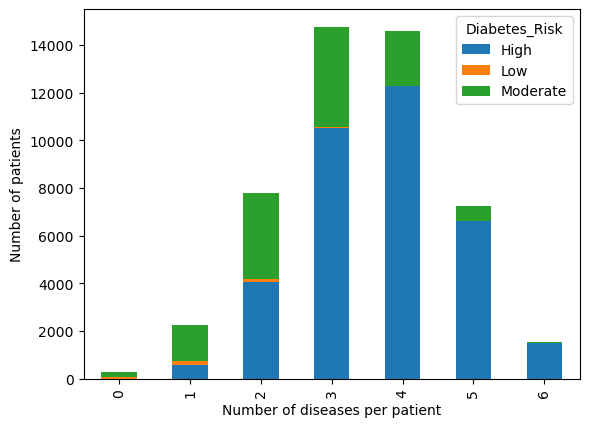

In [136]:
#count the "Yes" per row, giving an overview of number of recorded health issues per patient
diabetes_df['#_diseases'] = diabetes_df.eq("Yes").sum(axis=1)
print(diabetes_df.head())
#distribution of #diseases

datastack_DR_NumD = pd.crosstab(diabetes_df['#_diseases'],
 diabetes_df['Diabetes_Risk'])
datastack_DR_NumD.plot(kind='bar',stacked=True)
plt.xlabel("Number of diseases per patient")
plt.ylabel("Number of patients")
plt.show()

#Conclusion, # of diseases seems strongly correlated to diabetes risk

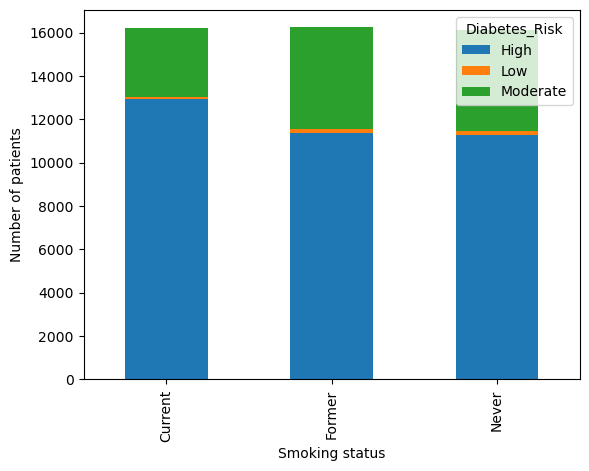

In [137]:
datastack_DR_NumD = pd.crosstab(diabetes_df['Smoking_Status'],
 diabetes_df['Diabetes_Risk'])
datastack_DR_NumD.plot(kind='bar',stacked=True)
plt.xlabel("Smoking status")
plt.ylabel("Number of patients")
plt.show()


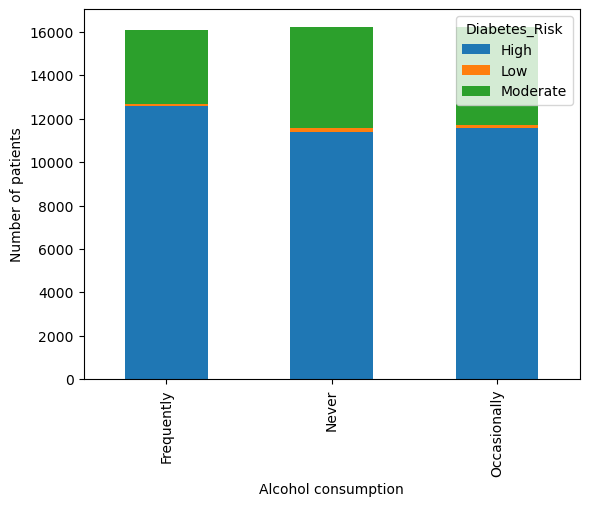

In [138]:

datastack_DR_NumD = pd.crosstab(diabetes_df['Alcohol_Consumption'],
 diabetes_df['Diabetes_Risk'])
datastack_DR_NumD.plot(kind='bar',stacked=True)
plt.xlabel("Alcohol consumption")
plt.ylabel("Number of patients")
plt.show()


In [ ]:
#Fasting blood sugar is a diagnosis criteria, more than a risk factor
#It will not be included in the final model
#HbA1c is a representation of the average blood sugar over 2-3months and is thus also
#a diagnostic criteria rather than a risk factor and will also be dropped
# AI_Health_Recommendation is not a physiological or lifestyle trait. This too will be dropped
columns_to_drop = ['Fasting_Blood_Sugar','AI_Health_Recommendation', 'HbA1c']
diabetes_df = diabetes_df.drop(columns=[col for col in columns_to_drop if col in diabetes_df.columns])

Machine learning; finding most influential factors

In [140]:
#import machine learning tools
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


In [141]:
#Feature selection
target = diabetes_df[['Diabetes_Risk_Score']]
features = diabetes_df.drop(
    columns=['Diabetes_Risk', 'Diabetes_Risk_Score'])
non_numeric_cols = features.select_dtypes(
    exclude="number").columns
features = pd.get_dummies(
    features,
    columns=non_numeric_cols,
    dtype=int)

print(f"Number_of_features: {features.shape[1]}")

target_train, target_test, feat_train, feat_test = train_test_split(
    target, features, test_size=0.2, random_state=42)


rfg = RandomForestRegressor

model = rfg(
    n_estimators=50,
    random_state=42,
    n_jobs=-1)

print('Diabetes_Risk_Score' in feat_train.columns)
print('Diabetes_Risk_Score' in feat_test.columns)


model.fit(feat_train,target_train)

print(model.feature_names_in_)


print("Features:", features.shape)
print("Train features:", feat_train.shape)
print("Test features:", feat_test.shape)

print("Model expects:", model.n_features_in_)
print("Feature importances:", len(model.feature_importances_))
print("Test columns:", len(feat_test.columns))

Number_of_features: 88
False
False


c:\Users\nicol\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


['Patient_ID' 'Age' 'BMI' 'Waist_Circumference_cm' 'Blood_Glucose'
 'Insulin_Level' 'Blood_Pressure_Systolic' 'Blood_Pressure_Diastolic'
 'Total_Cholesterol' 'HDL' 'LDL' 'Triglycerides' 'Heart_Rate'
 'Exercise_Hours_Per_Week' 'Daily_Walking_Minutes' 'Sleep_Hours'
 'Daily_Water_Intake_L' '#_diseases' 'Gender_Female' 'Gender_Male'
 'Gender_Other' 'Country_Argentina' 'Country_Australia'
 'Country_Bangladesh' 'Country_Brazil' 'Country_Canada' 'Country_China'
 'Country_Egypt' 'Country_France' 'Country_Germany' 'Country_India'
 'Country_Indonesia' 'Country_Italy' 'Country_Japan' 'Country_Malaysia'
 'Country_Mexico' 'Country_Nigeria' 'Country_Pakistan' 'Country_Russia'
 'Country_Saudi Arabia' 'Country_South Africa' 'Country_South Korea'
 'Country_Spain' 'Country_Turkey' 'Country_United Kingdom'
 'Country_United States' 'Physical_Activity_Level_High'
 'Physical_Activity_Level_Low' 'Physical_Activity_Level_Moderate'
 'Physical_Activity_Level_Unknown' 'Diet_Quality_Average'
 'Diet_Quality_Health

In [142]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,
    feat_test,
    target_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error")

importance = pd.DataFrame({
    "feature": feat_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std}).sort_values(
    "importance_mean",
    ascending=False)



In [143]:
importance_df = pd.DataFrame(importance)
display(importance_df)

,feature,importance_mean,importance_std
17,#_diseases,57.454887,1.202123
1,Age,31.653604,0.829600
2,BMI,24.586183,0.366308
6,Blood_Pressure_Systolic,11.895784,0.516396
86,Doctor_Consultation_Needed_No,11.434395,0.430635
52,Diet_Quality_Poor,8.601621,0.452796
47,Physical_Activity_Level_Low,8.378697,0.590622
87,Doctor_Consultation_Needed_Yes,6.755163,0.342583
8,Total_Cholesterol,5.332314,0.403403
59,Smoking_Status_Current,4.474802,0.377167
